# LAB 2.2 - Bonus Track

Capacity analysis: how performance changes while incrementally storing all 10 digit patterns.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

from hopfield_numpy import HopfieldNetwork, distort_pattern, load_patterns


In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "lab2_2_alldigits"
PLOT_DIR = PROJECT_ROOT / "figures" / "bonus_track"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

patterns = load_patterns(DATA_DIR)
print("Loaded patterns:", patterns.shape)


Loaded patterns: (10, 1024)


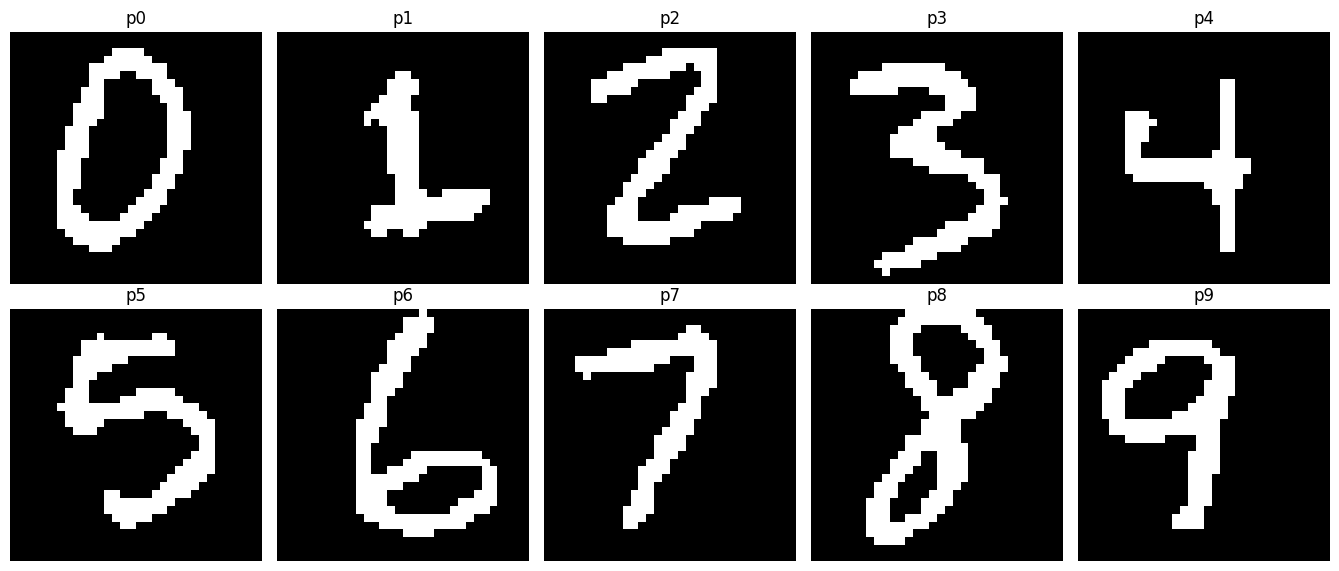

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(13.5, 5.8))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(patterns[idx].reshape(32, 32), cmap="gray")
    ax.set_title(f"p{idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [4]:
noise = 0.05
net = HopfieldNetwork(patterns[:3])

def compute_avg_discrepancy(reconstructions: np.ndarray, targets: np.ndarray) -> float:
    avg = 0.0
    for i in range(reconstructions.shape[0]):
        avg += float(np.mean((reconstructions[i] - targets[i]) ** 2))
    return avg / reconstructions.shape[0]

avg_discrepancy = []
overlaps = {}
reconstructions = np.zeros_like(patterns, dtype=float)

distortions = [
    distort_pattern(patterns[0], noise, seed=42),
    distort_pattern(patterns[1], noise, seed=42),
    distort_pattern(patterns[2], noise, seed=42),
]

for i in range(3, 11):
    overlap = []

    for k in range(0, i):
        result = net.recall(distortions[k], patterns[k], bias=0.5)
        reconstructions[k] = result.recalled
        overlap.append(result.overlaps)

    avg_discrepancy.append(compute_avg_discrepancy(reconstructions[: i - 1], patterns[: i - 1]))
    overlaps[i] = overlap

    if i == 10:
        break

    print(f"Learning new pattern {i}...")
    net.incremental_store(patterns[i])
    distortions.append(distort_pattern(patterns[i], noise, seed=42))


Learning new pattern 3...
Learning new pattern 4...


Learning new pattern 5...


Learning new pattern 6...


Learning new pattern 7...


Learning new pattern 8...


Learning new pattern 9...


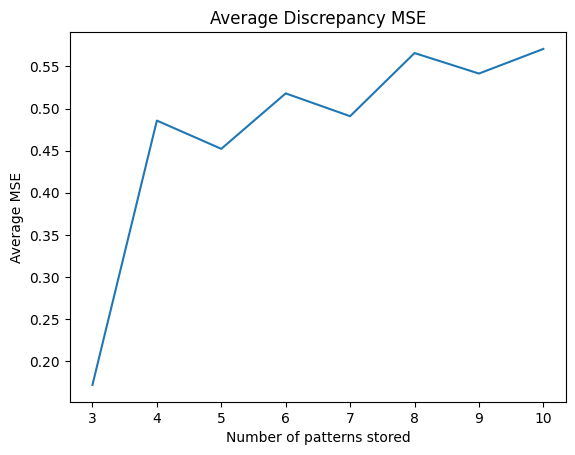

In [5]:
plt.plot(range(3, 11), avg_discrepancy)
plt.xlabel("Number of patterns stored")
plt.ylabel("Average MSE")
plt.title("Average Discrepancy MSE")
plt.savefig(PLOT_DIR / "avg_discrepancy.png")
plt.show()


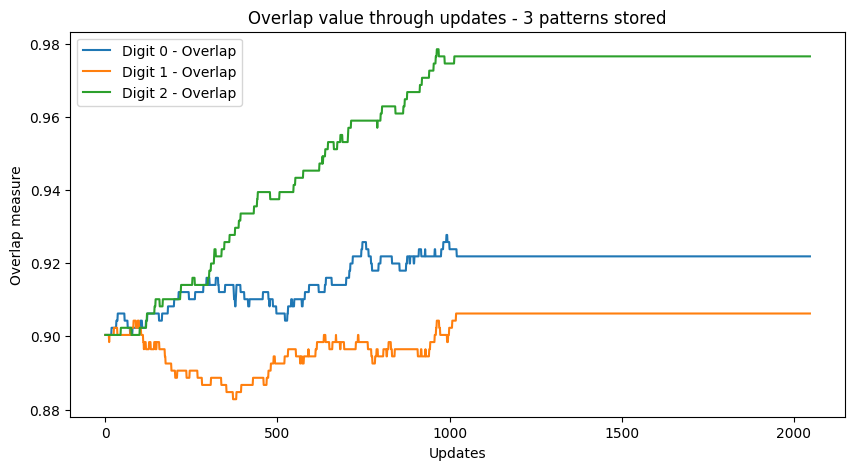

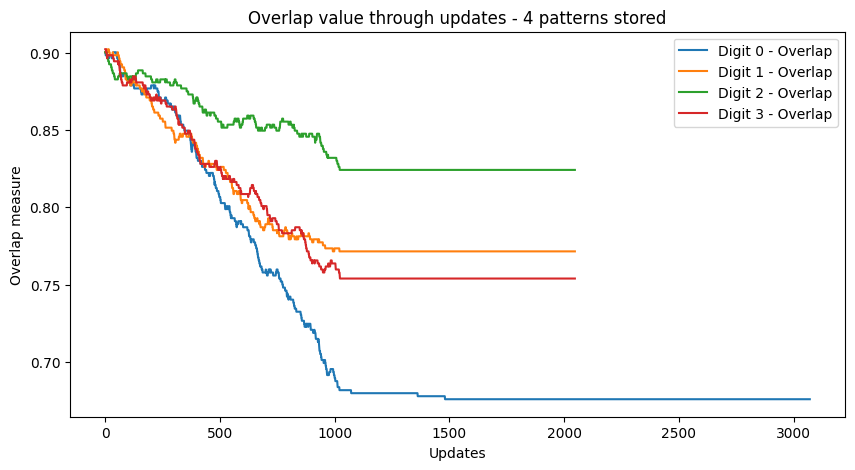

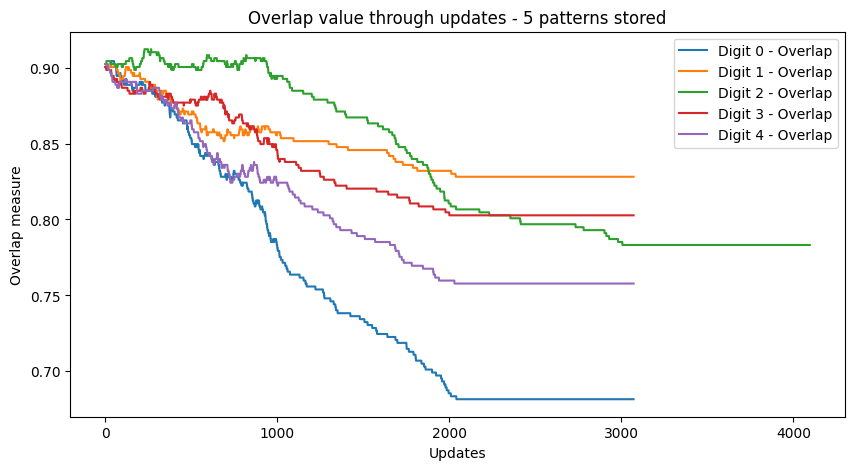

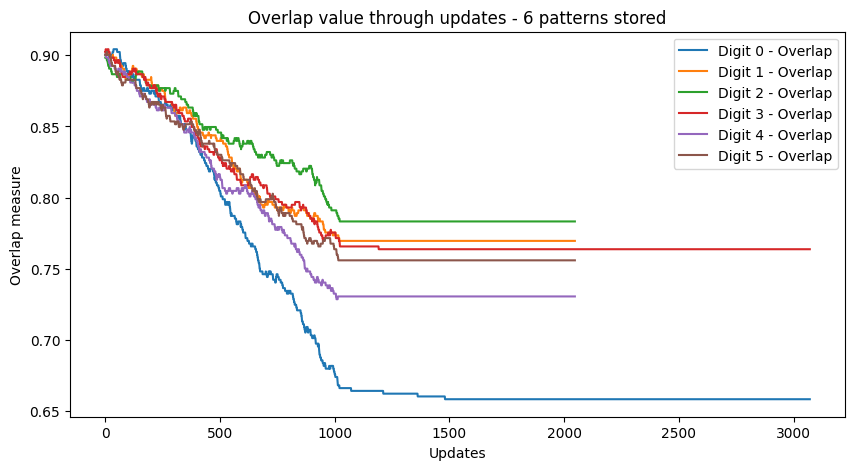

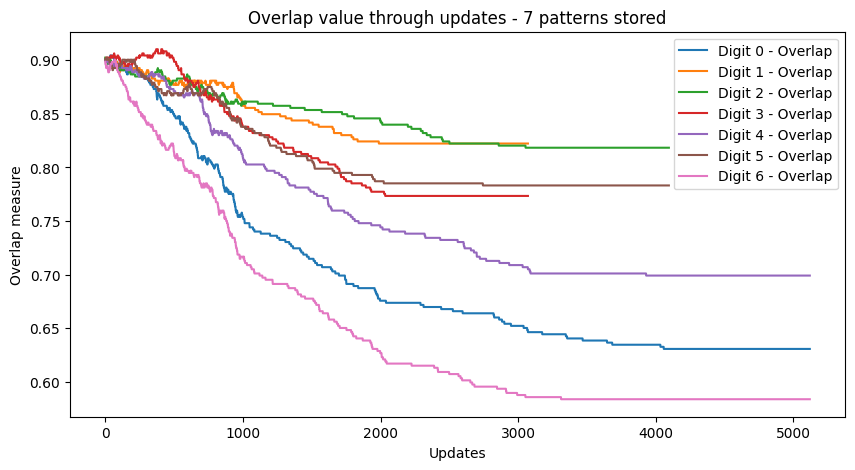

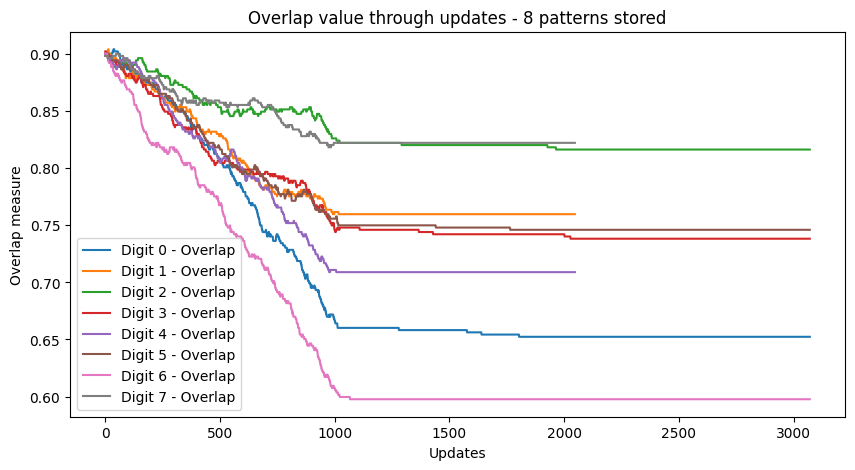

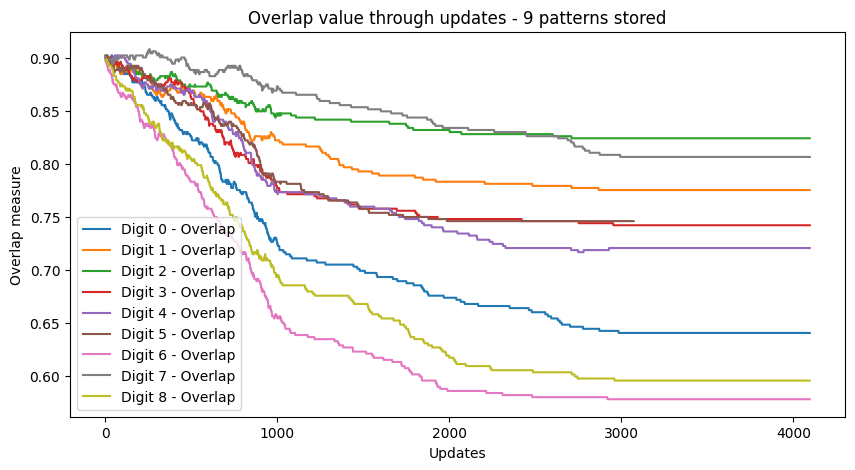

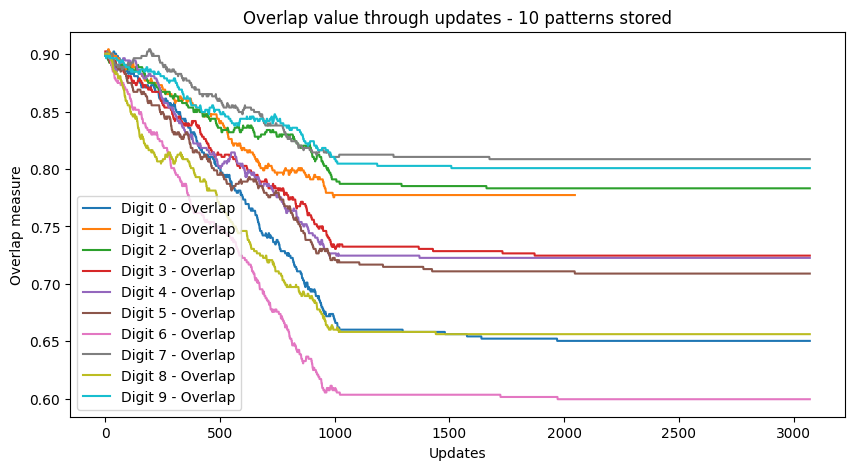

In [6]:
def plot_overlaps(overlap: list[np.ndarray], patterns_count: int) -> None:
    plt.figure(figsize=(10, 5))
    plt.title(f"Overlap value through updates - {patterns_count} patterns stored")
    plt.xlabel("Updates")
    plt.ylabel("Overlap measure")

    for i, ov in enumerate(overlap):
        plt.plot(ov, label=f"Digit {i} - Overlap")

    plt.legend()
    plt.savefig(PLOT_DIR / f"overlap_with_{patterns_count}_digit.png")
    plt.show()


for key, overlap in overlaps.items():
    plot_overlaps(overlap, key)
